In [1]:
# Standard library
import random
import matplotlib.pyplot as plt
# Data manipulation
import numpy as np
import pandas as pd

# Visualization
import matplotlib.pyplot as plt
import seaborn as sns

# Machine learning
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import (
    mean_squared_error,
    mean_absolute_error,
    mean_absolute_percentage_error,
    r2_score
)
from sklearn.model_selection import (
    KFold)

from sklearn.inspection import PartialDependenceDisplay
import math

# Custom utilities
from sklearn.preprocessing import StandardScaler

import utils.cross_validation as cval
from utils.model_utils import data_processing_v2, train_test_split_v2

import xgboost as xgb
import shap

/home/qli/Projects/env1/lib/python3.12/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [2]:
biome_mapping = {
    0: 'Boreal and Tundra forests',
    1: 'Flooded grasslands',
    2: 'Mangroves',
    3: 'Mediterranean woodlands',
    4: 'Temperate broadleaf forests',
    5: 'Temperate conifer forests',
    6: 'Temperate grasslands',
    7: 'Tropical',
    8: 'Tropical',
    9: 'Tropical',
    10: 'Tropical',
    11: 'Boreal and Tundra forests',
    12: 'Xeric shrublands',
    13: 'Unknown'
}


In [5]:

fd_df = pd.read_csv('data/final/final_dataset_with_aridity.csv')
fd_df.drop(columns=[ 'managed', 'ownership','Functional_Divergences', 'Shannon Equitabiltiy Index',
       'managed.1'], inplace=True)

fd_df.dropna(inplace=True)

ecoregions=cval.process_ecoregion("data/Ecoregions/Ecoregions2017.shp")

ecoregions=ecoregions[['ECO_NAME', 'geometry']]

#Preprocessing the data for Random forest regression
fbiome_dfs= data_processing_v2(fd_df, biome_mapping, ecoregions)

In [6]:
fd_df['biome'].value_counts()

biome
Temperate conifer forests      41780
Temperate grasslands           20460
Tropical                       15027
Unknown                         1194
Mediterranean woodlands          215
Xeric shrublands                 143
Boreal and Tundra forests        116
Flooded grasslands                43
Temperate broadleaf forests       27
Mangroves                         14
Name: count, dtype: int64

In [7]:
biome_list=['Boreal and Tundra forests', 'Temperate conifer forests', 'Xeric shrublands',
            'Mediterranean woodlands' , 'Temperate broadleaf forests',
            'Tropical', 'Temperate grasslands',
            'Unknown', ]


## Random Forest

In [9]:
def quick_eval(model, X_test, y_test, biome_name=None, feature_names=None, 
               show_shap=True, figsize=(16, 10)):
    """
    Comprehensive model evaluation with hexbin scatter plot and SHAP feature importance.
    
    Parameters:
    - model: trained model
    - X_test: test features
    - y_test: test targets
    - biome_name: (optional) name for title
    - feature_names: (optional) feature names for SHAP plot
    - show_shap: whether to show SHAP importance
    - figsize: overall figure size
    
    Returns:
    - fig: matplotlib figure
    - metrics: dict with MAE and R2 scores
    """
    
    # Make predictions
    y_pred = model.predict(X_test)
    
    # Calculate metrics
    mae = mean_absolute_error(y_test, y_pred, multioutput='raw_values')
    r2 = r2_score(y_test, y_pred, multioutput='raw_values')
    
    # Ensure arrays
    y_test = np.array(y_test)
    y_pred = np.array(y_pred)
    n_outputs = y_test.shape[1] if y_test.ndim > 1 else 1
    
    # Determine layout
    if show_shap:
        # 2 rows: hexbin on top, SHAP on bottom
        fig = plt.figure(figsize=figsize)
        gs = fig.add_gridspec(2, n_outputs, height_ratios=[1, 1.2], hspace=0.3)
    else:
        # Only hexbin plots
        fig, axes = plt.subplots(1, n_outputs, figsize=(5 * n_outputs, 4), squeeze=False)
        gs = None
    
    # --- HEXBIN SCATTER PLOTS ---
    if show_shap:
        hex_axes = [[fig.add_subplot(gs[0, i]) for i in range(n_outputs)]]
    else:
        hex_axes = axes
    
    for i in range(n_outputs):
        ax = hex_axes[0][i] if n_outputs > 1 else hex_axes[0][0]
        if n_outputs > 1:
            y_t = y_test[:, i]
            y_p = y_pred[:, i]
        else:
            y_t = y_test
            y_p = y_pred
        
        # Hexbin plot
        hb = ax.hexbin(y_t, y_p, gridsize=40, cmap='YlOrRd', mincnt=1)
        fig.colorbar(hb, ax=ax, label='Count')
        
        # Perfect fit line
        min_val = min(y_t.min(), y_p.min())
        max_val = max(y_t.max(), y_p.max())
        ax.plot([min_val, max_val], [min_val, max_val], 'r--', lw=1.5, label='Perfect fit')
        
        # Labels and title
        ax.set_xlabel('Actual')
        ax.set_ylabel('Predicted')
        ax.set_title(f'Output {i+1} | MAE: {mae[i]:.3f} | R²: {r2[i]:.3f}')
        ax.legend()
        ax.grid(True, alpha=0.3)
    
    # --- SHAP FEATURE IMPORTANCE ---
    if show_shap:
        # Create SHAP explainer
        explainer = shap.TreeExplainer(model)
        shap_values = explainer.shap_values(X_test)
        
        # Handle feature names
        if feature_names is None:
            feature_names = X_test.columns if hasattr(X_test, 'columns') else [f'Feature {i}' for i in range(X_test.shape[1])]
        
        # Get mean absolute SHAP values
        if isinstance(shap_values, list):
            # Multi-output case - use first output or average
            shap_mean = np.abs(shap_values[0]).mean(axis=0)
        else:
            shap_mean = np.abs(shap_values).mean(axis=0)
        
        # Sort features by importance
        sorted_idx = np.argsort(shap_mean)[::-1]
        top_n = min(20, len(feature_names))
        
        # Create SHAP bar plot in the bottom subplot(s)
        if n_outputs > 1:
            # For multi-output, use the first subplot for SHAP
            ax_shap = fig.add_subplot(gs[1, 0])
            # Clear other bottom subplots
            for i in range(1, n_outputs):
                empty_ax = fig.add_subplot(gs[1, i])
                empty_ax.axis('off')
        else:
            ax_shap = fig.add_subplot(gs[1, 0])
        
        # Create bar plot
        colors = ['#4b72f1'] * top_n
        bars = ax_shap.barh(range(top_n), shap_mean[sorted_idx[:top_n]], color=colors)
        
        # Customize
        ax_shap.set_yticks(range(top_n))
        ax_shap.set_yticklabels([feature_names[i] for i in sorted_idx[:top_n]])
        ax_shap.set_xlabel('Mean |SHAP value|', fontsize=11)
        ax_shap.set_title(f'SHAP Feature Importance{": " + biome_name if biome_name else ""}', 
                         fontsize=13, fontweight='bold')
        ax_shap.invert_yaxis()  # Most important at top
        ax_shap.grid(True, alpha=0.3, axis='x')
        
        # Add value labels
        for i, (bar, val) in enumerate(zip(bars, shap_mean[sorted_idx[:top_n]])):
            ax_shap.text(val + val*0.02, i, f'{val:.3f}', va='center', fontsize=8)
    
    # Overall title
    if show_shap:
        title = f'Model Performance & SHAP Importance'
        if biome_name:
            title += f' - {biome_name}'
        fig.suptitle(title, fontsize=14, fontweight='bold', y=0.98)
    
    plt.tight_layout()
    plt.show()
    
    # Return metrics
    metrics = {
        'MAE': mae.tolist() if hasattr(mae, 'tolist') else mae,
        'R2': r2.tolist() if hasattr(r2, 'tolist') else r2,
        'n_outputs': n_outputs
    }
    
    return fig, metrics

Biome: Boreal and Tundra forests


/tmp/ipykernel_1000026/819369890.py:129: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


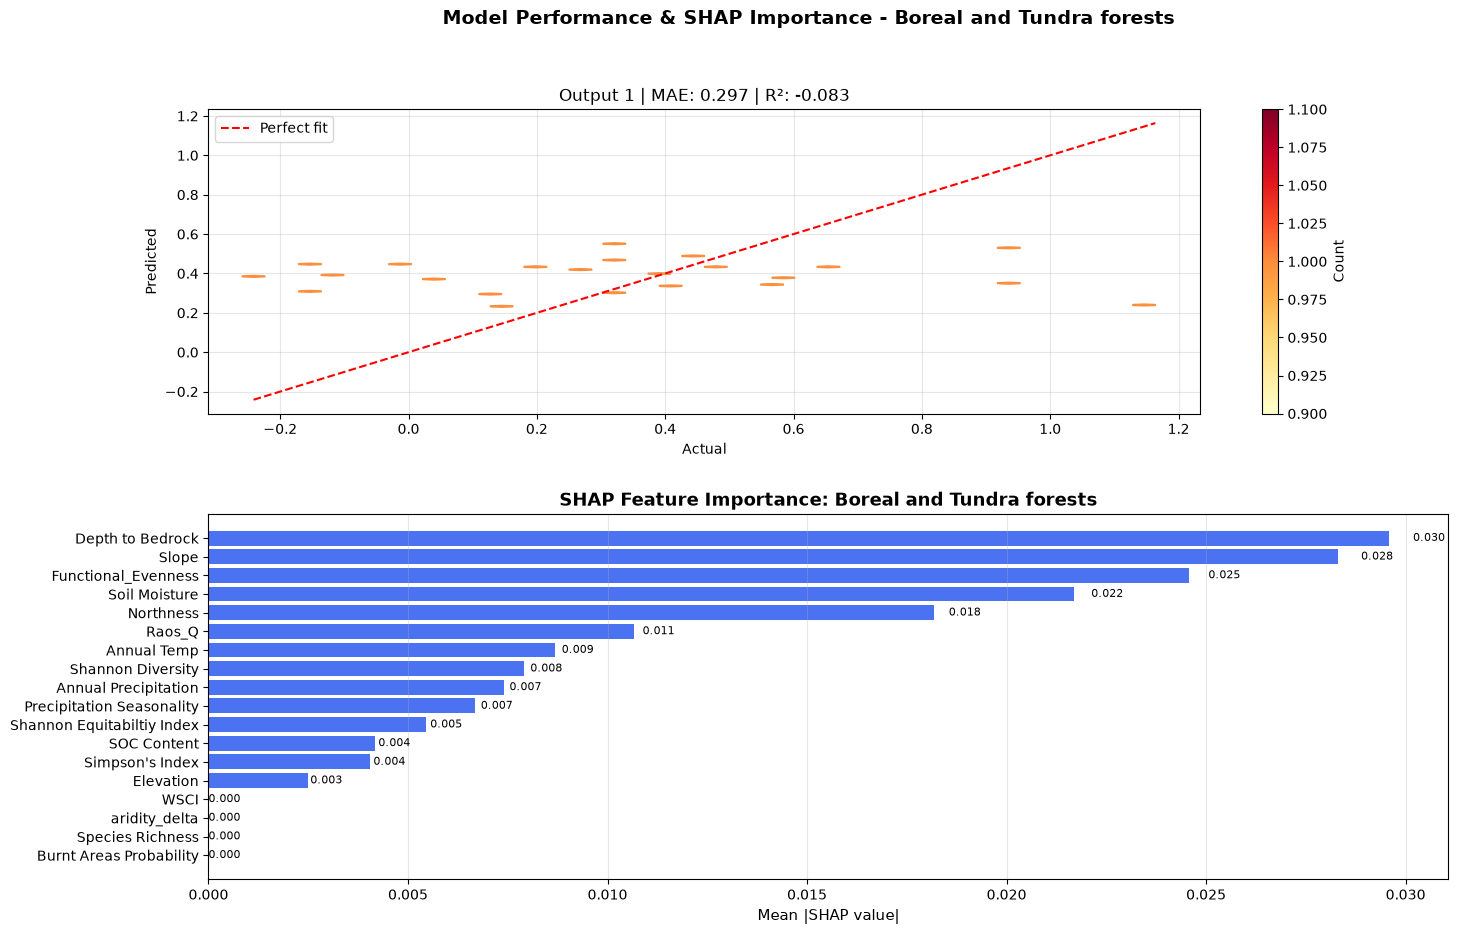

Biome: Temperate conifer forests


KeyboardInterrupt: 

In [10]:
test_size=0.2
random_key=42

rf_params = {
    'n_estimators': 200,          # Fewer trees for simpler model
    'max_depth': 6,               # Shallower = more interpretable
    'min_samples_split': 10,
    'min_samples_leaf': 5,
    'max_features': 'sqrt',
    'n_jobs': -1,
    'random_state': 42
    }
for biome in biome_list:
    print(f"Biome: {biome}")

    random.seed(random_key)

    n_points= round(len(fbiome_dfs[biome])*test_size)
    fX_train, fy_train, fX_test, fy_test = train_test_split_v2(fbiome_dfs[biome], random_key=random_key, n_points_to_select=n_points, buffer_km=50)
    
    model = RandomForestRegressor(**rf_params)
    model.fit(fX_train, fy_train)
    fig, metrics = quick_eval(
        model=model,
        X_test=fX_test,
        y_test=fy_test,
        biome_name=biome,
        feature_names=fX_test.columns.tolist(),
        show_shap=True
    )

## XGBoost

In [8]:
''' Parameter tuning for XGBoost regression models for each biome.
# Define hyperparameters
biome = 'Temperate conifer forests'
params = {"objective": "reg:squarederror", "learning_rate": 0.025, "tree_method":'approx'} # Temperate conifer forests
n = 240

biome = 'Boreal and Tundra forests'
params = {"objective": "reg:squarederror",
           "learning_rate": 0.05,  
          'max_depth': 6,
           'min_child_weight': 5,        # Increased from 3
            'gamma': 0.1,                # Added
            'reg_lambda': 2.0,           # Increased from 1
            'reg_alpha': 0.5,  "tree_method":'approx'} 
n_rounds = 30

biome = 'Xeric shrublands'
params = {"objective": "reg:squarederror",
           "learning_rate": 0.05,  
          'max_depth': 6,
           'min_child_weight': 5,        # Increased from 3
            'gamma': 0.1,                # Added
            'reg_lambda': 2.0,           # Increased from 1
            'reg_alpha': 0.5,  "tree_method":'approx'} 
n = 50


biome = 'Temperate grasslands'
params = {"objective": "reg:squarederror",
           "learning_rate": 0.05,  
          'max_depth': 6,
           'min_child_weight': 5,        # Increased from 3
            'gamma': 0.1,                # Added
            'reg_lambda': 2.0,           # Increased from 1
            'reg_alpha': 0.5,  "tree_method":'approx'} 
n_rounds= 80



biome =  'Mediterranean woodlands' # Random Forest actually does better wow This is just bad lol 
params = {"objective": "reg:squarederror",
           "learning_rate": 0.05,  
          'max_depth': 6,
           'min_child_weight': 5,        # Increased from 3
            'gamma': 0.1,                # Added
            'reg_lambda': 2.0,           # Increased from 1
            'reg_alpha': 0.5,  "tree_method":'approx'} 
n = 50

biome = 'Temperate broadleaf forests'
params = {"objective": "reg:squarederror",
           "learning_rate": 0.001,  
          'max_depth': 6,
           'min_child_weight': 5,        # Increased from 3
            'gamma': 0.1,                # Added
            'reg_lambda': 3.0,           # Increased from 1
            'reg_alpha': 0.5,  "tree_method":'approx'} 
n = 10

biome = 'Tropical'
params = {"objective": "reg:squarederror",
           "learning_rate": 0.005,  
          'max_depth': 6,
           'min_child_weight': 5,        # Increased from 3
            'gamma': 0.1,                # Added
            'reg_lambda': 2.0,           # Increased from 1
            'reg_alpha': 0.5,  "tree_method":'approx'} 
n = 250

'''

' Parameter tuning for XGBoost regression models for each biome.\n# Define hyperparameters\nbiome = \'Temperate conifer forests\'\nparams = {"objective": "reg:squarederror", "learning_rate": 0.025, "tree_method":\'approx\'} # Temperate conifer forests\nn = 240\n\nbiome = \'Boreal and Tundra forests\'\nparams = {"objective": "reg:squarederror",\n           "learning_rate": 0.05,  \n          \'max_depth\': 6,\n           \'min_child_weight\': 5,        # Increased from 3\n            \'gamma\': 0.1,                # Added\n            \'reg_lambda\': 2.0,           # Increased from 1\n            \'reg_alpha\': 0.5,  "tree_method":\'approx\'} \nn_rounds = 30\n\nbiome = \'Xeric shrublands\'\nparams = {"objective": "reg:squarederror",\n           "learning_rate": 0.05,  \n          \'max_depth\': 6,\n           \'min_child_weight\': 5,        # Increased from 3\n            \'gamma\': 0.1,                # Added\n            \'reg_lambda\': 2.0,           # Increased from 1\n            \

In [9]:
def evaluate_xgboost(model, dtrain, dtest, X_test, y_test, feature_names=None, 
                     biome_name=None, show_shap=True, figsize=(12, 14)):
    """
    Comprehensive XGBoost model evaluation with hexbin scatter plot (top) 
    and SHAP feature importance (bottom).
    
    Parameters:
    - model: trained XGBoost model
    - dtrain: training DMatrix (for SHAP explainer)
    - dtest: test DMatrix (for SHAP explainer) 
    - X_test: test features (pandas DataFrame or numpy array)
    - y_test: test targets
    - feature_names: (optional) feature names for SHAP plot
    - biome_name: (optional) name for title
    - show_shap: whether to show SHAP importance
    - figsize: overall figure size (width, height)
    
    Returns:
    - fig: matplotlib figure
    - metrics: dict with MAE, R2, RMSE scores
    """
    
    # Make predictions
    y_pred = model.predict(dtest)
    
    # Calculate metrics
    mae = mean_absolute_error(y_test, y_pred)
    r2 = r2_score(y_test, y_pred)
    rmse = np.sqrt(mean_squared_error(y_test, y_pred))
    
    print(f"=== XGBoost Model Performance ===")
    print(f"MAE: {mae:.4f}")
    print(f"R²: {r2:.4f}")
    print(f"RMSE: {rmse:.4f}")
    
    # Create figure with 2 rows: scatter plot on top, SHAP below
    if show_shap:
        fig, axes = plt.subplots(2, 1, figsize=figsize, 
                                 gridspec_kw={'height_ratios': [1.2, 1]})
        ax_scatter = axes[0]
        ax_shap = axes[1]
    else:
        fig, ax_scatter = plt.subplots(1, 1, figsize=(figsize[0], figsize[1]//1.5))
    
    # --- HEXBIN SCATTER PLOT (TOP) ---
    hb = ax_scatter.hexbin(y_test, y_pred, gridsize=40, cmap='YlOrRd', mincnt=1)
    cbar = fig.colorbar(hb, ax=ax_scatter, label='Count')
    cbar.ax.tick_params(labelsize=9)
    
    # Perfect fit line
    min_val = min(y_test.min(), y_pred.min())
    max_val = max(y_test.max(), y_pred.max())
    ax_scatter.plot([min_val, max_val], [min_val, max_val], 'r--', lw=2, label='Perfect fit')
    
    # Add 10% error bands (optional)
    ax_scatter.plot([min_val, max_val], [min_val*1.1, max_val*1.1], 'gray', lw=1, alpha=0.5, linestyle=':')
    ax_scatter.plot([min_val, max_val], [min_val*0.9, max_val*0.9], 'gray', lw=1, alpha=0.5, linestyle=':')
    
    ax_scatter.set_xlabel('Actual', fontsize=11)
    ax_scatter.set_ylabel('Predicted', fontsize=11)
    title = f'XGBoost: Predicted vs Actual'
    if biome_name:
        title += f' - {biome_name}'
    ax_scatter.set_title(title, fontsize=13, fontweight='bold')
    
    # Add metrics text box
    metrics_text = f'MAE: {mae:.4f}\nR²: {r2:.4f}\nRMSE: {rmse:.4f}\nn: {len(y_test)}'
    ax_scatter.text(0.05, 0.95, metrics_text, transform=ax_scatter.transAxes,
                    fontsize=10, verticalalignment='top',
                    bbox=dict(boxstyle='round', facecolor='white', alpha=0.8))
    
    ax_scatter.legend(loc='lower right', fontsize=9)
    ax_scatter.grid(True, alpha=0.3)
    
    # --- SHAP FEATURE IMPORTANCE (BOTTOM) ---
    if show_shap:
        try:
            import shap
            
            # Create SHAP explainer
            explainer = shap.TreeExplainer(model)
            shap_values = explainer.shap_values(dtest)
            
            # Get feature names
            if feature_names is None:
                if hasattr(X_test, 'columns'):
                    feature_names = X_test.columns.tolist()
                else:
                    feature_names = [f'Feature_{i}' for i in range(X_test.shape[1])]
            
            # Mean absolute SHAP values
            shap_mean = np.abs(shap_values).mean(axis=0)
            
            # Sort by importance
            sorted_idx = np.argsort(shap_mean)[::-1]
            top_n = min(15, len(feature_names))  # Reduced to 15 for better visibility
            
            # Create bar plot
            colors = plt.cm.Blues(np.linspace(0.4, 0.9, top_n))[::-1]
            bars = ax_shap.barh(range(top_n), shap_mean[sorted_idx[:top_n]], color=colors)
            
            # Customize
            ax_shap.set_yticks(range(top_n))
            ax_shap.set_yticklabels([feature_names[i] for i in sorted_idx[:top_n]], fontsize=10)
            ax_shap.set_xlabel('Mean |SHAP value|', fontsize=11)
            ax_shap.set_title('SHAP Feature Importance', fontsize=13, fontweight='bold')
            ax_shap.invert_yaxis()
            ax_shap.grid(True, alpha=0.3, axis='x')
            
            # Add value labels
            for i, (bar, val) in enumerate(zip(bars, shap_mean[sorted_idx[:top_n]])):
                ax_shap.text(val + val*0.02, i, f'{val:.3f}', va='center', fontsize=8)
                
        except Exception as e:
            ax_shap.text(0.5, 0.5, f'SHAP Error:\n{str(e)}', 
                        ha='center', va='center', transform=ax_shap.transAxes,
                        fontsize=12)
            print(f"Warning: SHAP plot failed - {e}")
    
    plt.tight_layout()
    plt.show()
    
    # Return metrics
    metrics = {
        'MAE': mae,
        'R2': r2,
        'RMSE': rmse,
        'n_samples': len(y_test)
    }
    
    return fig, metrics


def smooth_pdp(x_vals, y_vals, window=50):
    df = pd.DataFrame({'x': x_vals, 'y': y_vals}).sort_values('x')
    df['y_smooth'] = df['y'].rolling(window, center=True, min_periods=1).mean()
    return df['x'].values, df['y_smooth'].values


def haversine(lat1, lon1, lat2, lon2):
    """Calculate great-circle distance between two points in km"""
    R = 6371  # Earth's radius in km
    
    lat1, lon1, lat2, lon2 = map(radians, [lat1, lon1, lat2, lon2])
    dlat = lat2 - lat1
    dlon = lon2 - lon1
    
    a = sin(dlat/2)**2 + cos(lat1) * cos(lat2) * sin(dlon/2)**2
    c = 2 * asin(sqrt(a))
    
    return R * c

from math import radians, sin, cos, sqrt, asin

def select_points_stratified(df, n_per_biome=5, biome_col='biome', buffer_km=50,
                            lat_col='lat', lon_col='lon', random_seed=None):
    """
    Select exactly n_per_biome points from each biome.
    
    Parameters:
    - df: DataFrame with coordinates
    - n_per_biome: number of points to select per biome
    - biome_col: column name for biome
    - lat_col: latitude column name
    - lon_col: longitude column name
    - random_seed: random seed for reproducibility
    
    Returns:
    - selected_data: DataFrame with selected points
    - selected_indices: indices of selected points
    - biomes_sampled: dict with biome names and number sampled
    """
    
    if random_seed is not None:
        np.random.seed(random_seed)
    
    # Get biomes present
    biomes = df[biome_col].unique()
    
    selected_indices = []
    biomes_sampled = {}
    
    for biome in biomes:
        # Get indices for this biome
        biome_indices = df[df[biome_col] == biome].index.tolist()
        
        if len(biome_indices) < n_per_biome:
            print(f"Warning: Biome '{biome}' has only {len(biome_indices)} points, "
                  f"sampling all {len(biome_indices)}")
            n_to_sample = len(biome_indices)
        else:
            n_to_sample = n_per_biome
        
        # Randomly select points
        selected = np.random.choice(biome_indices, n_to_sample, replace=False)
        selected_indices.extend(selected)
        biomes_sampled[biome] = len(selected)
    
    # Get selected data
    selected_data = df.loc[selected_indices].copy()
    # Get unique coordinates (if needed)
    selected_coords = selected_data[[lat_col, lon_col]].drop_duplicates().reset_index(drop=True)
    all_coords = df[[lat_col, lon_col]].drop_duplicates().reset_index(drop=True)

    selected_points = []
    removed_points = []
    remaining_points = []

    for idx, row in all_coords.iterrows():
        lat = row[lat_col]
        lon = row[lon_col]
        
        # If this point IS selected, keep it
        if idx in selected_indices:
            selected_points.append(idx)
            continue
        
        # Check distance to ALL selected points
        within_buffer = False
        for _, sel_row in selected_coords.iterrows():
            dist = haversine(lat, lon, sel_row[lat_col], sel_row[lon_col])
            if dist <= buffer_km:
                within_buffer = True
                break  # No need to check more, it's within buffer of at least one
        
        if within_buffer:
            removed_points.append(idx)  # Too close to a selected point → remove
        else:
            remaining_points.append(idx)  # Far enough from all selected points → keep

    # Create DataFrames
    selected_df = df.iloc[selected_points].copy()
    removed_df = df.iloc[removed_points].copy()
    remaining_df = df.iloc[remaining_points].copy()
    
    return selected_df, remaining_df, removed_df

def train_test_split_v3(df, random_key, n_points_to_select=5, buffer_km=100):
    sub_df = df

    selected, remaining, removed = select_points_stratified(sub_df, 
        n_per_biome=n_points_to_select,
        buffer_km=buffer_km,
        lat_col='lat',
        lon_col='lon',
        random_seed=random_key
    )

    test = selected.drop(columns=['lat', 'lon', 'biome'])
    test_biomes=selected[['biome']]
    train= remaining.drop(columns=['lat', 'lon', 'biome'])

    y=['transformed npp'] 
    X_train=train.drop(columns=y+['PID'])
    y_train = train['transformed npp'].values

    X_test= test.drop(columns=y+['PID' ])
    y_test = test['transformed npp'].values
    
    scaler= StandardScaler()
    X_train = pd.DataFrame(scaler.fit_transform(X_train), columns=X_train.columns, index=X_train.index)
    X_test = pd.DataFrame(scaler.transform(X_test), columns=X_test.columns, index=X_test.index)

    return X_train, y_train, X_test, y_test, test_biomes

In [10]:
random_key=111

fX_train, fy_train, fX_test, fy_test, test_biomes = train_test_split_v3(fd_df, random_key=random_key, n_points_to_select=5, buffer_km=50)

# # Create regression matrices
dtrain_reg = xgb.DMatrix(fX_train, fy_train, enable_categorical=True)
dtest_reg = xgb.DMatrix(fX_test, fy_test, enable_categorical=True)


[0]	train-rmse:0.43910	validation-rmse:0.55436
[1]	train-rmse:0.43330	validation-rmse:0.54889
[2]	train-rmse:0.42763	validation-rmse:0.54355
[3]	train-rmse:0.42208	validation-rmse:0.53833
[4]	train-rmse:0.41666	validation-rmse:0.53322
[5]	train-rmse:0.41136	validation-rmse:0.52822
[6]	train-rmse:0.40618	validation-rmse:0.52334
[7]	train-rmse:0.40112	validation-rmse:0.51857
[8]	train-rmse:0.39618	validation-rmse:0.51391
[9]	train-rmse:0.39158	validation-rmse:0.51007
[10]	train-rmse:0.38712	validation-rmse:0.50557
[11]	train-rmse:0.38242	validation-rmse:0.50178
[12]	train-rmse:0.37845	validation-rmse:0.49805
[13]	train-rmse:0.37424	validation-rmse:0.49460
[14]	train-rmse:0.37016	validation-rmse:0.49092
[15]	train-rmse:0.36617	validation-rmse:0.48684
[16]	train-rmse:0.36258	validation-rmse:0.48344
[17]	train-rmse:0.35842	validation-rmse:0.47944
[18]	train-rmse:0.35436	validation-rmse:0.47553
[19]	train-rmse:0.35034	validation-rmse:0.47267
[20]	train-rmse:0.34647	validation-rmse:0.46894
[2

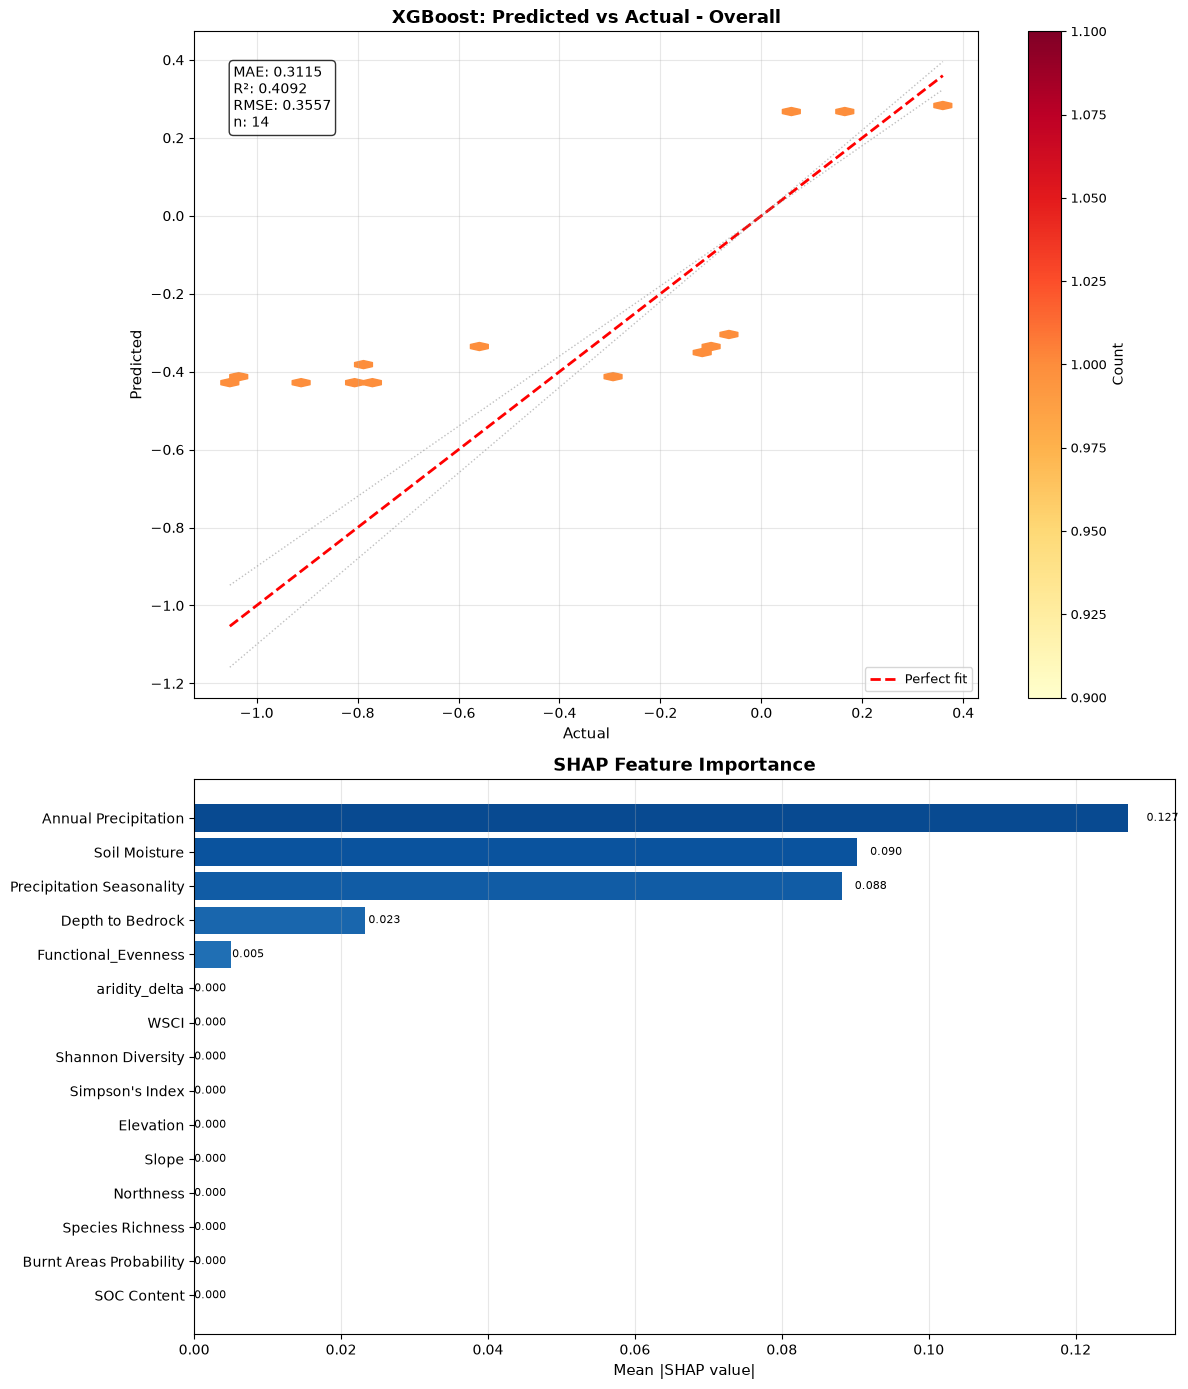

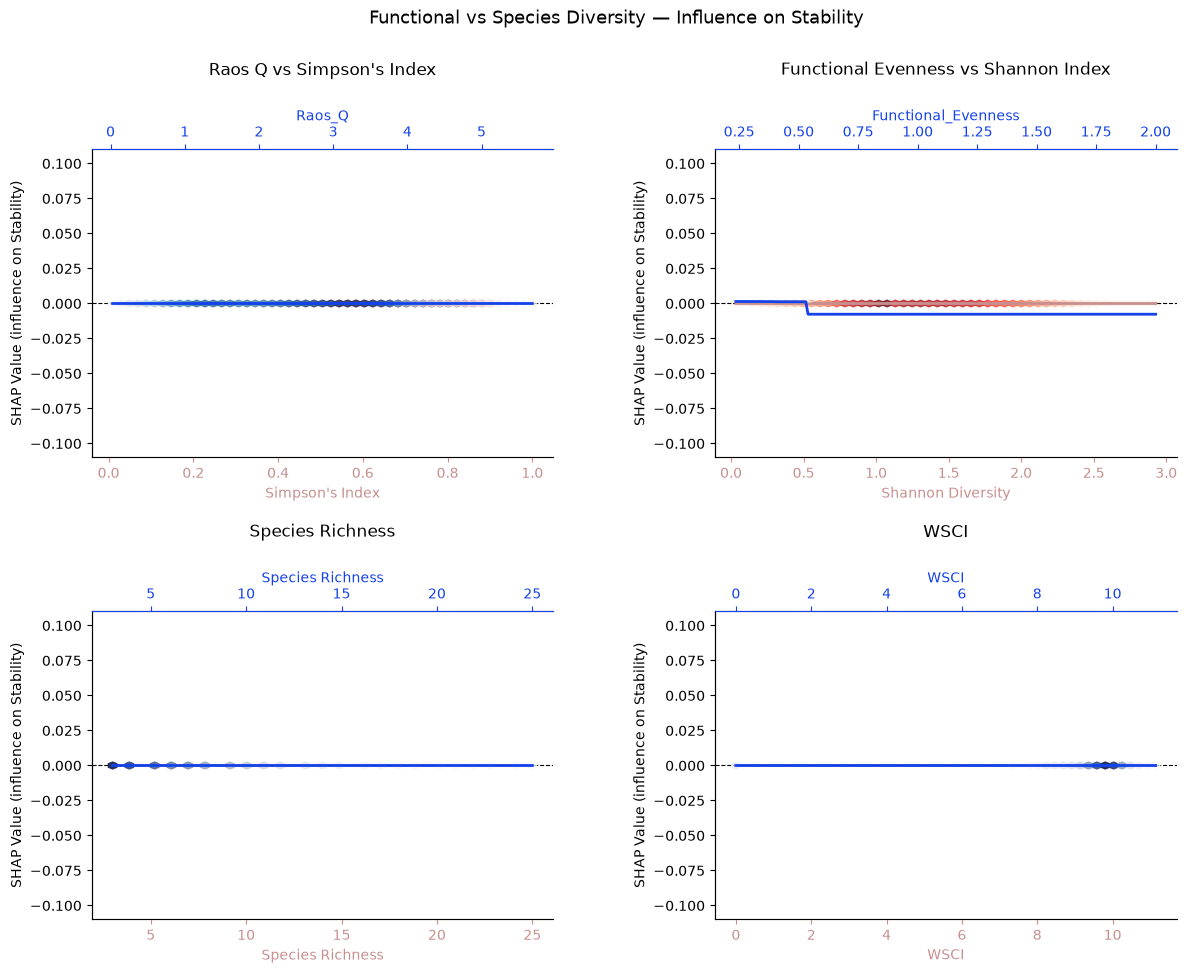

In [19]:
params = {"objective": "reg:squarederror",
           "learning_rate": 0.02,  
          'max_depth': 6,
           'min_child_weight': 8,        # Increased from 3
            'gamma': 0.3,                # Added
            'reg_lambda': 2.0,           # Increased from 1
            'reg_alpha': 0.5,  "tree_method":'hist'} 
n_rounds = 450
evals = [(dtrain_reg, "train"), (dtest_reg, "validation")]

# model = xgb.train(
#    params=params,
#    dtrain=dtrain_reg,
#    num_boost_round=n_rounds,
# )

model = xgb.train(
   params=params,
   dtrain=dtrain_reg,
   num_boost_round=n_rounds,
   evals=evals,
)

# # Evaluate
fig, metrics = evaluate_xgboost(
    model=model,
    dtrain=dtrain_reg,
    dtest=dtest_reg,
    X_test=fX_test,
    y_test=fy_test,
    feature_names=fX_test.columns.tolist(),
    biome_name='Overall',
    show_shap=True
)

explainer = shap.TreeExplainer(model)

X=fd_df.drop(columns=['transformed npp', 'PID', 'lat', 'lon', 'biome'])

shap_vals = explainer.shap_values(xgb.DMatrix(X))


# Each tuple: (functional/top feature, species/bottom feature, title)
pairs = [
   ('Raos_Q',               "Simpson's Index",    "Raos Q vs Simpson's Index"),
   ('Functional_Evenness', 'Shannon Diversity',      "Functional Evenness vs Shannon Index"),
   ('Species Richness',     "Species Richness",   "Species Richness"),
   ('WSCI',                 "WSCI",               "WSCI"),
]

colors_top    = "#1341ea"
colors_bottom = "#c88f8f"
fig, axes = plt.subplots(2, 2, figsize=(14, 10))
axes_flat = axes.flatten()
fig.subplots_adjust(hspace=0.5, wspace=0.35)

for ax, (top_feat, bot_feat, title) in zip(axes_flat, pairs):
    top_idx = X.columns.tolist().index(top_feat)
    bot_idx = X.columns.tolist().index(bot_feat)

    x_top = X[top_feat].values
    y_top = shap_vals[:, top_idx]
    x_bot = X[bot_feat].values
    y_bot = shap_vals[:, bot_idx]

    # Bottom axis — species diversity
    ax.hexbin(x_bot, y_bot, gridsize=50, cmap='Reds', alpha=0.7, mincnt=1)
    x_smooth_bot, y_smooth_bot = smooth_pdp(x_bot, y_bot, window=200)
    ax.plot(x_smooth_bot, y_smooth_bot, color=colors_bottom, linewidth=2, zorder=5)
    ax.set_xlabel(bot_feat, color=colors_bottom)
    ax.tick_params(axis='x', colors=colors_bottom)
    ax.spines['bottom'].set_color(colors_bottom)

    # Top axis — functional diversity
    ax_top = ax.twiny()
    ax_top.hexbin(x_top, y_top, gridsize=50, cmap='Blues', alpha=0.7, mincnt=1)
    x_smooth_top, y_smooth_top = smooth_pdp(x_top, y_top, window=200)
    ax_top.plot(x_smooth_top, y_smooth_top, color=colors_top, linewidth=2, zorder=5)
    ax_top.set_xlabel(top_feat, color=colors_top)
    ax_top.tick_params(axis='x', colors=colors_top)
    ax_top.spines['top'].set_color(colors_top)

    ax.set_ylabel("SHAP Value (influence on Stability)")
    ax.set_title(title, pad=25)
    ax.axhline(0, color='black', linewidth=0.8, linestyle='--')
    ax.spines['right'].set_visible(False)
    ax_top.spines['right'].set_visible(False)

plt.suptitle("Functional vs Species Diversity — Influence on Stability",
             fontsize=13, y=1.02)
# plt.savefig("shap_density.png", dpi=150, bbox_inches="tight")
plt.show()

In [12]:
results = {}

fy_series = pd.Series(fy_test.flatten(), index=fX_test.index, name='transformed npp')
combined = fX_test.join(fy_series).join(test_biomes)


for biome, group in combined.groupby('biome'):   # missing 'group'
    X = group.drop(columns=['transformed npp', 'biome'])  # use group not combined
    y = group[['transformed npp']]                                               # use group not combined

    dmatrix = xgb.DMatrix(X, enable_categorical=True)
    preds   = model.predict(dmatrix)

    results[biome]            = preds
    results[f'{biome}_mae']   = mean_absolute_error(y, preds)
    results[f'{biome}_rmse']  = np.sqrt(mean_squared_error(y, preds))
    results[f'{biome}_mape']  = mean_absolute_percentage_error(y, preds)
    results[f'{biome}_r2']    = r2_score(y, preds)

# Summary
print(f"{'Biome':<40} {'MAE':>8} {'RMSE':>8} {'MAPE':>8} {'R2':>8}")
print("-" * 80)
for biome in combined['biome'].unique():
    print(f"{biome:<40} {results[f'{biome}_mae']:>8.3f} {results[f'{biome}_rmse']:>8.3f} {results[f'{biome}_mape']:>8.3f} {results[f'{biome}_r2']:>8.3f}")


Biome                                         MAE     RMSE     MAPE       R2
--------------------------------------------------------------------------------
Temperate conifer forests                   0.084    0.106    0.484    0.391
Mangroves                                   0.515    0.718    0.558    0.398
Flooded grasslands                          0.460    0.478   22.093   -2.623
Temperate broadleaf forests                 0.420    0.471    6.542  -11.483
Boreal and Tundra forests                   0.237    0.274    0.374   -0.735
Xeric shrublands                            0.322    0.368    0.459   -0.937
Unknown                                     0.145    0.223    0.685    0.503
Temperate grasslands                        0.231    0.290    1.260    0.489
Mediterranean woodlands                     0.387    0.416    1.393   -1.386
Tropical                                    0.271    0.363    0.720    0.435


In [13]:
from umap import UMAP

# compute 2D embedding of SHAP values
s_2d = UMAP(
  n_components=2, n_neighbors=200, min_dist=0.5, random_state=random_key
).fit_transform(shap_vals)

/home/qli/Projects/env1/lib/python3.12/site-packages/umap/umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(


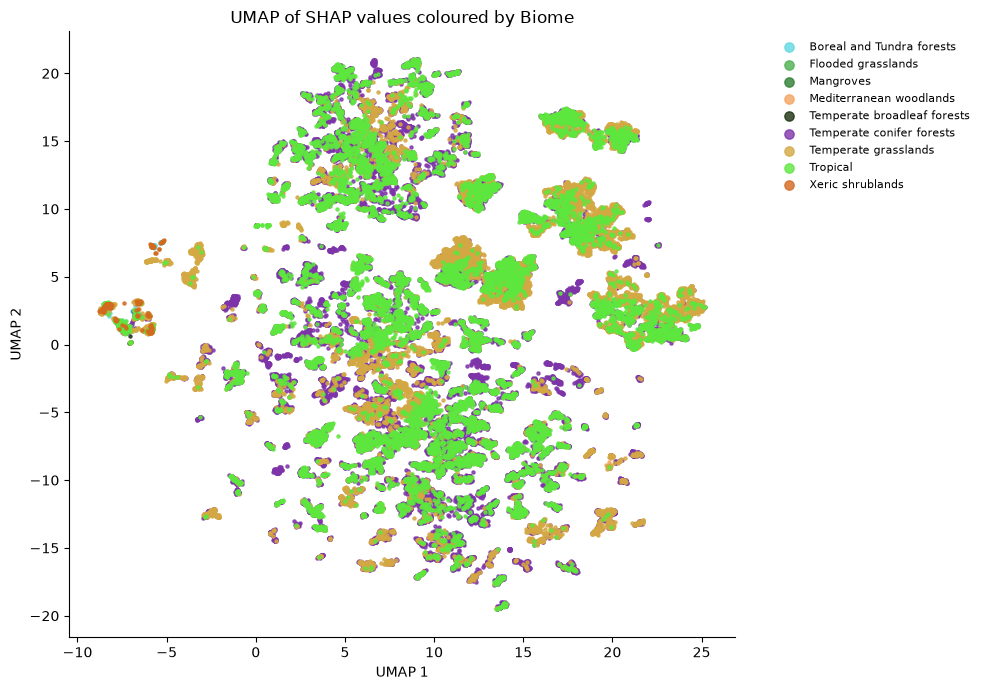

In [14]:
# Assuming you have biome in your original dataframe
# e.g. df['biome'] or a separate series aligned to X


biome_colors = {
    'Boreal and Tundra forests': "#62D7E0",        # boreal blue
    'Flooded grasslands': "#4CAF50",                # wetland green
    'Mangroves': "#2E7D32",                        # coastal green
    'Mediterranean woodlands': "#F4A460",          # sandy brown
    'Temperate broadleaf forests': "#1B3111",      # dark temperate green
    'Temperate conifer forests': "#7E34A9",        # purple conifer
    'Temperate grasslands': "#D4A843",             # golden
    'Tropical': "#5DE73E",                         # tropical green
    'Xeric shrublands': "#D2691E",                 # desert brown
}

fig, ax = plt.subplots(figsize=(10, 7))
biomes = fd_df['biome'].values  # numpy array of biome labels per row
for biome, color in biome_colors.items():
    mask = biomes == biome
    if mask.sum() == 0:
        continue
    ax.scatter(
        s_2d[mask, 0], s_2d[mask, 1],
        color=color,
        s=5,
        alpha=0.8,
        label=biome
    )

ax.set_xlabel("UMAP 1")
ax.set_ylabel("UMAP 2")
ax.set_title("UMAP of SHAP values coloured by Biome")
ax.legend(
    markerscale=3,
    bbox_to_anchor=(1.05, 1),
    loc='upper left',
    frameon=False,
    fontsize=8
)
ax.spines[['right', 'top']].set_visible(False)

plt.tight_layout()
plt.savefig("umap_biome.png", dpi=150, bbox_inches="tight")
plt.show()

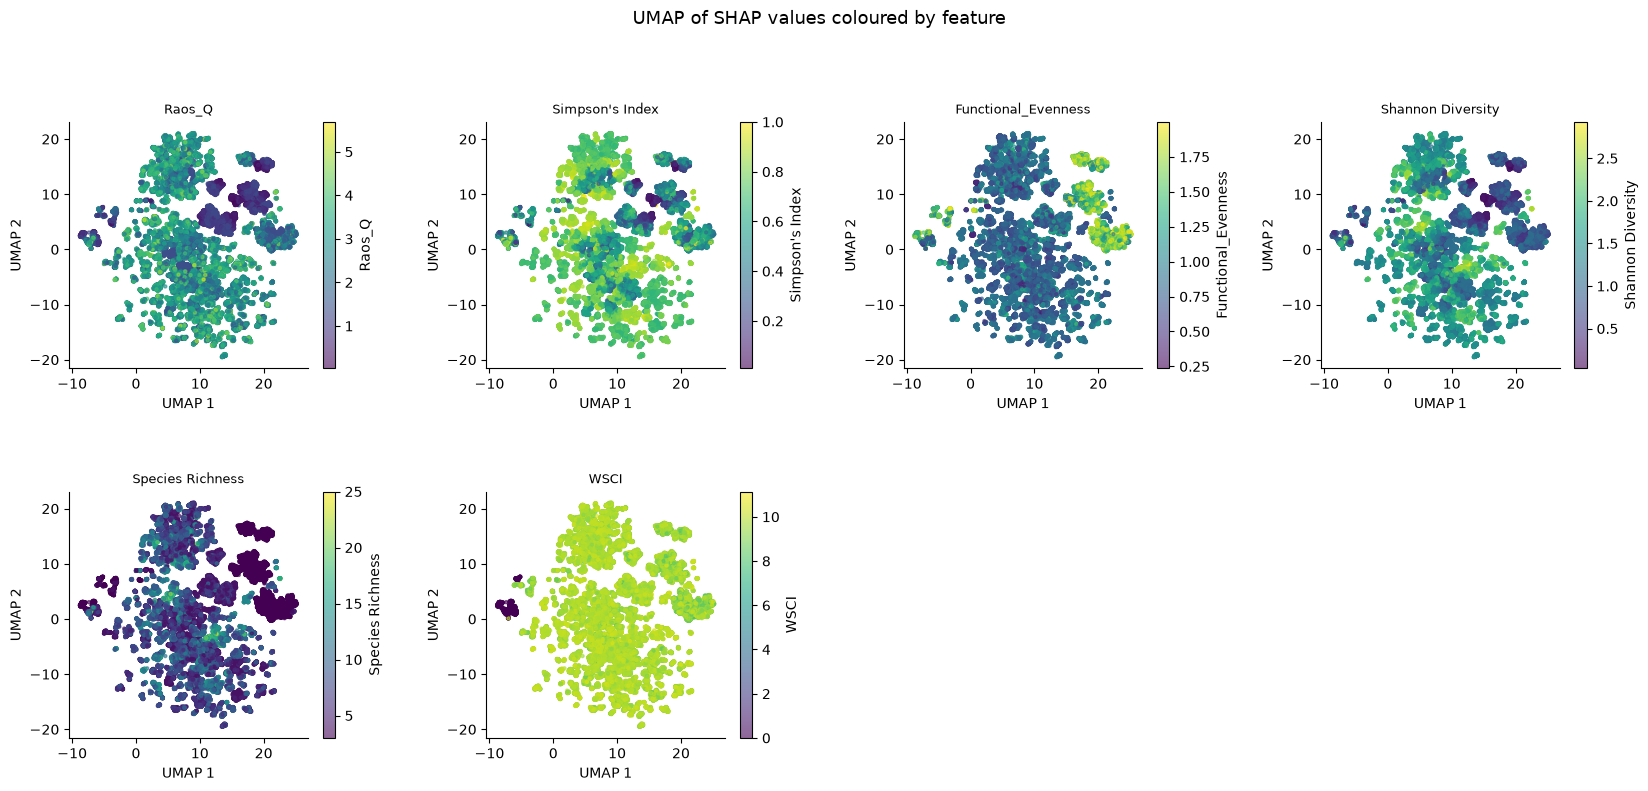

In [15]:
X=fd_df.drop(columns=['transformed npp', 'PID', 'lat', 'lon', 'biome'])

features = ['Raos_Q',  "Simpson's Index", 
    'Functional_Evenness', 'Shannon Diversity', 
    'Species Richness', 'WSCI']

# features = [feat for feat in X.columns if feat not in features]

ncols = 4
nrows = (len(features) + ncols - 1) // ncols

fig, axes = plt.subplots(nrows, ncols, figsize=(5 * ncols, 4 * nrows))
axes_flat = axes.flatten()
fig.subplots_adjust(hspace=0.5, wspace=0.4)

for ax, feat in zip(axes_flat, features):
    sc = ax.scatter(
        s_2d[:, 0], s_2d[:, 1],
        c=X[feat].values,
        cmap='viridis',
        s=5,
        alpha=0.6
    )
    plt.colorbar(sc, ax=ax, label=feat)
    ax.set_title(feat, fontsize=9)
    ax.set_xlabel("UMAP 1")
    ax.set_ylabel("UMAP 2")
    ax.spines[['right', 'top']].set_visible(False)

# Hide unused axes
for ax in axes_flat[len(features):]:
    ax.set_visible(False)

plt.suptitle("UMAP of SHAP values coloured by feature", fontsize=13, y=1.02)
# plt.savefig("umap_shap.png", dpi=150, bbox_inches="tight")
plt.show()

Temperate conifer forests
=== XGBoost Model Performance ===
MAE: 0.3360
R²: 0.3110
RMSE: 0.4625


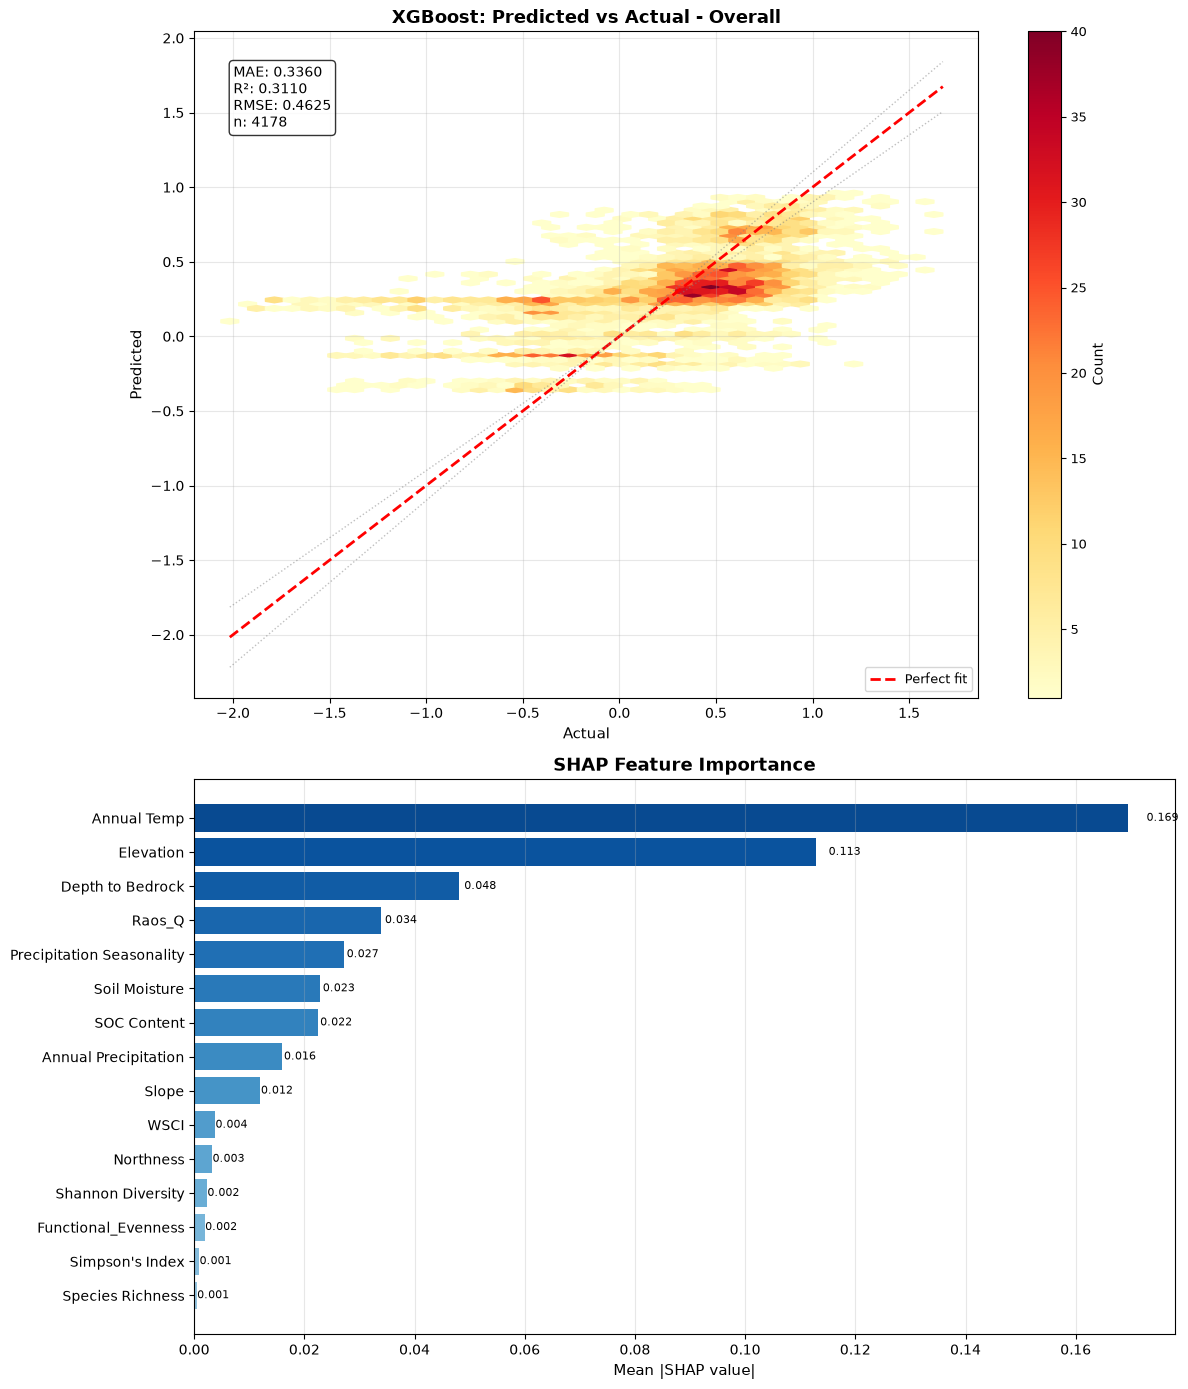

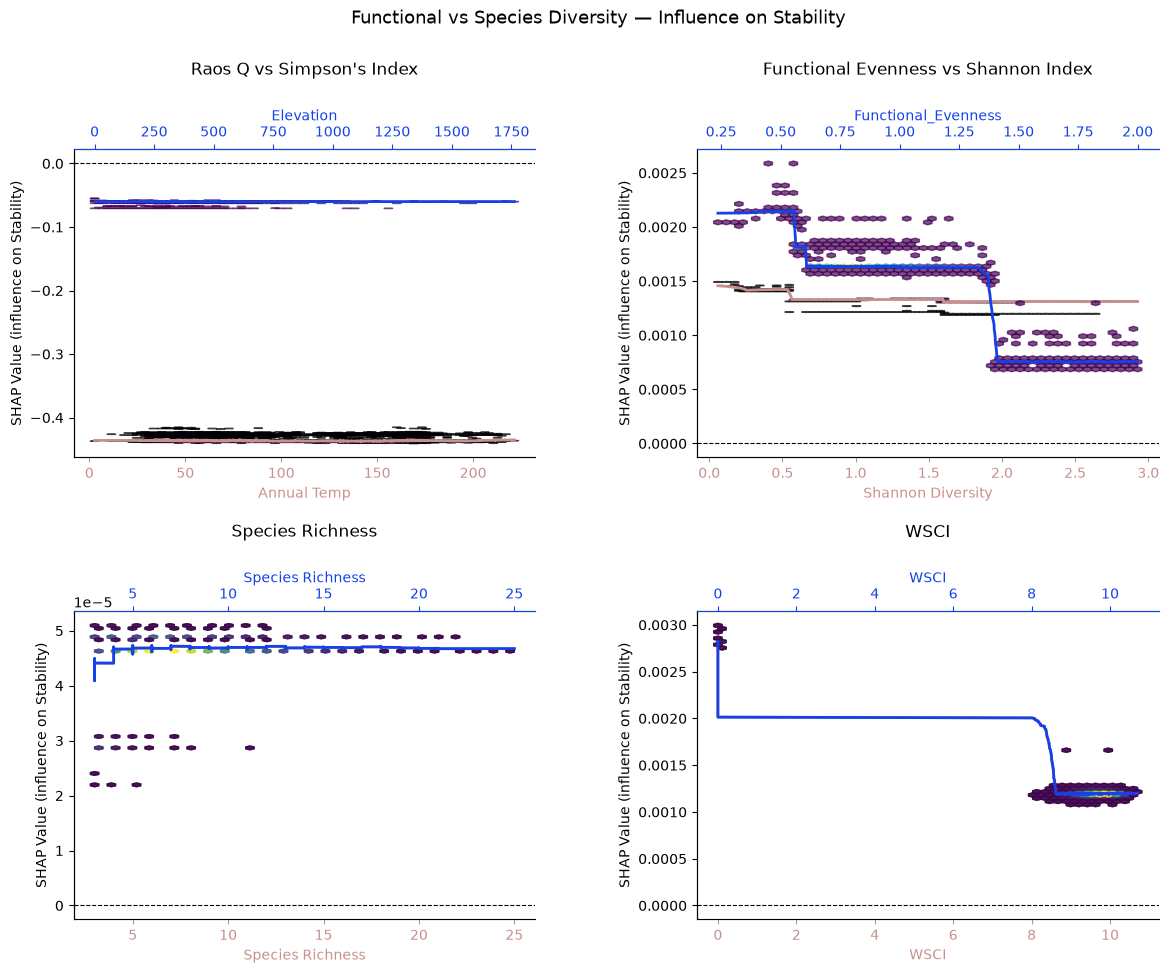

Tropical
=== XGBoost Model Performance ===
MAE: 0.4301
R²: 0.2876
RMSE: 0.5635


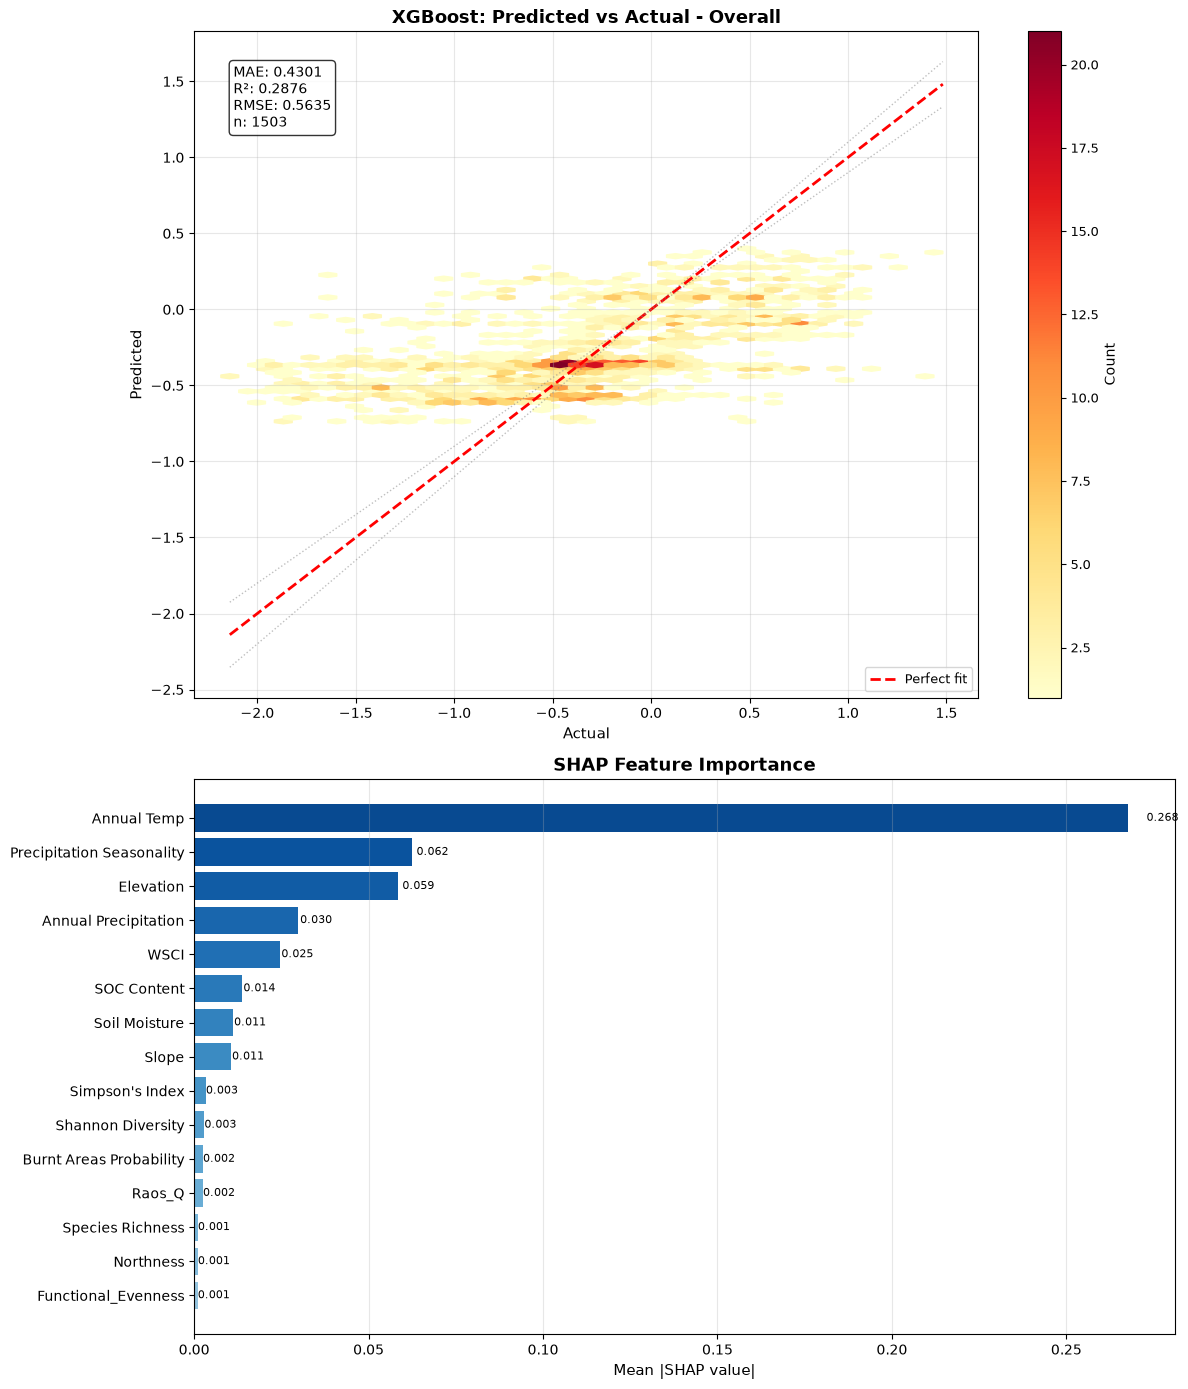

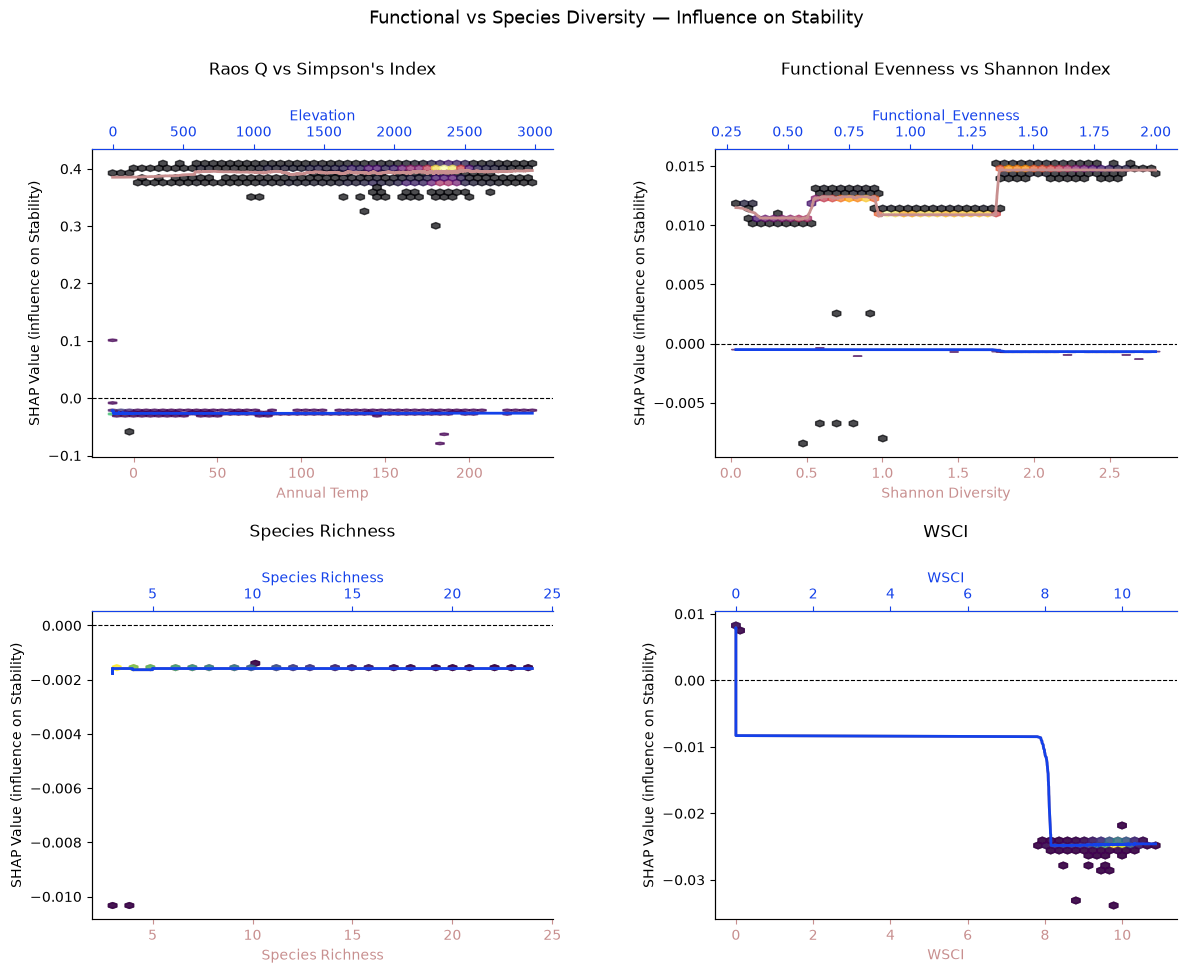

Xeric shrublands
=== XGBoost Model Performance ===
MAE: 0.3016
R²: 0.4404
RMSE: 0.3461


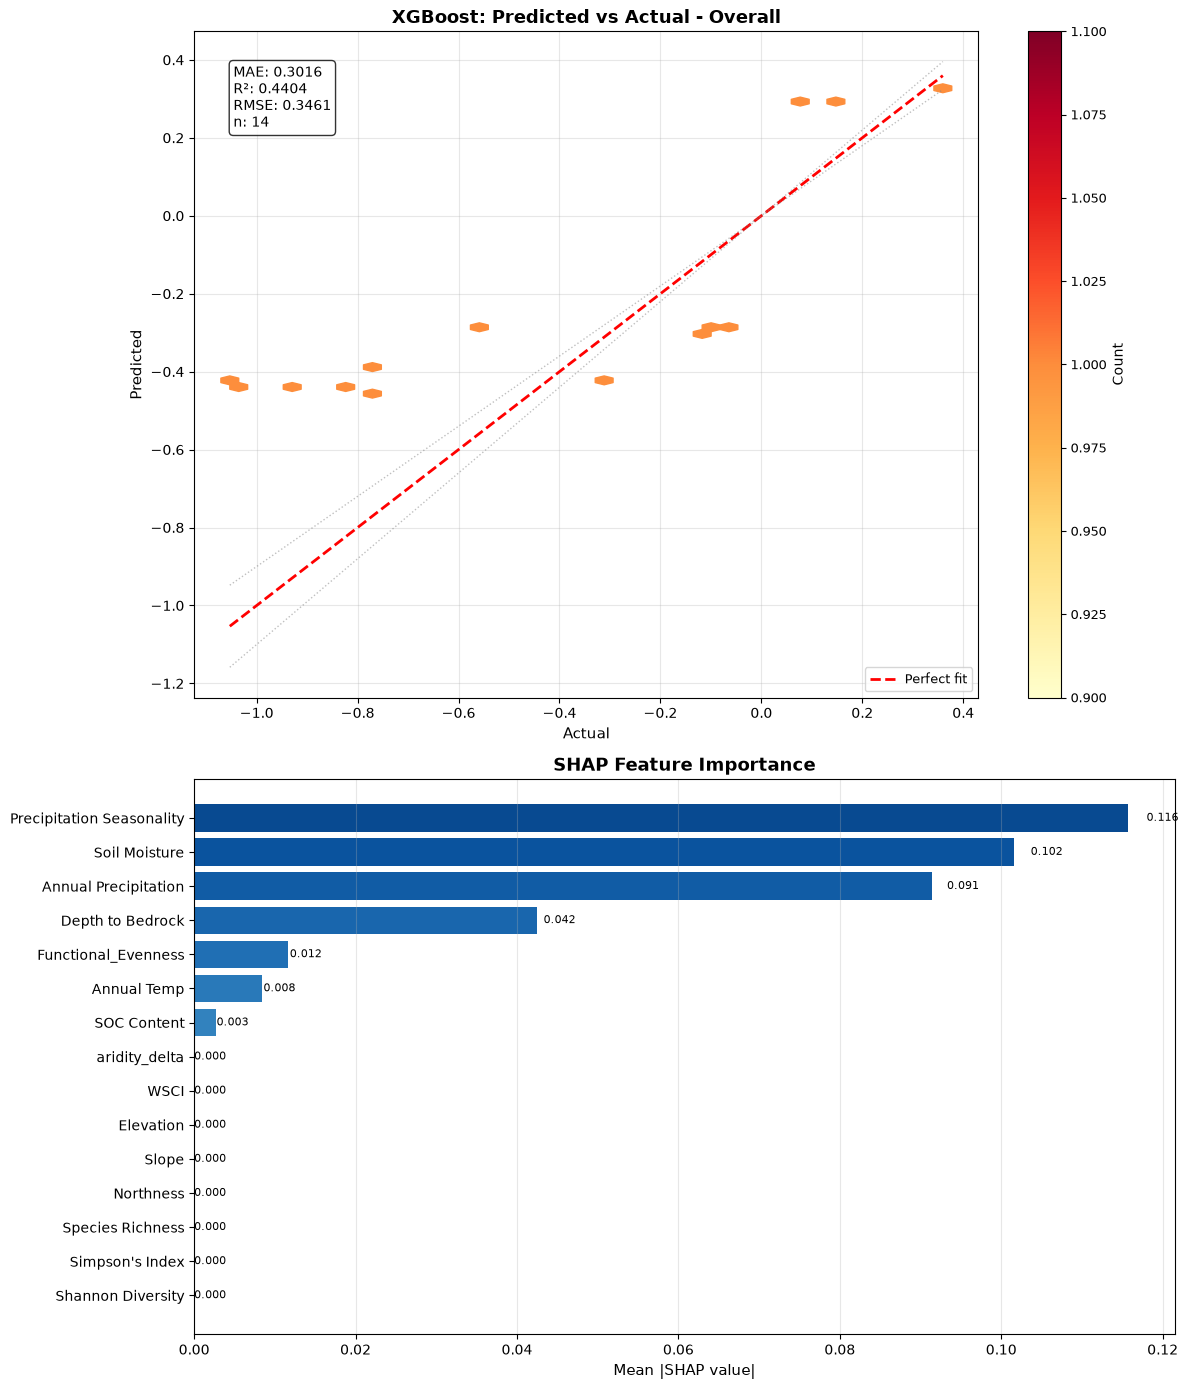

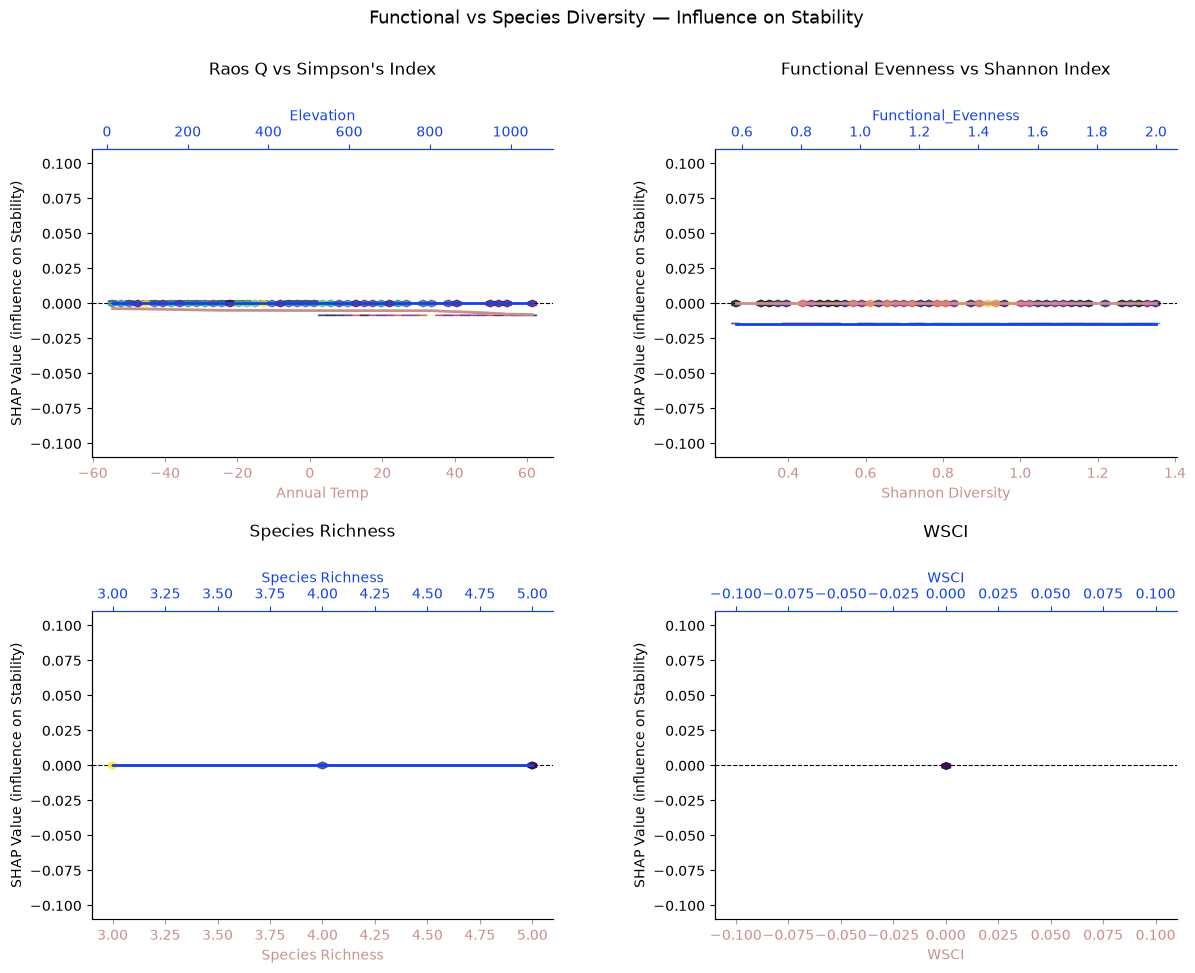

Temperate Broadleaf


KeyError: 'Temperate Broadleaf'

In [18]:
import xgboost as xgb
import pandas as pd
import shap

def smooth_pdp(x_vals, shap_vals, window=3):
    """Sort by x and apply rolling mean to smooth."""
    df = pd.DataFrame({'x': x_vals, 'y': shap_vals}).sort_values('x')
    df['y_smooth'] = df['y'].rolling(window, center=True, min_periods=1).mean()
    return df['x'].values, df['y_smooth'].values

# Define biome-specific configurations in a dictionary
biome_configs = {
    'Temperate conifer forests': {
        'params': {
            'objective': 'reg:squarederror',
            'learning_rate': 0.025,
            'tree_method': 'approx'
        },
        'n_rounds': 240
    },
    'Boreal and Tundra forests': {
        'params':  {"objective": "reg:squarederror",
           "learning_rate": 0.05,  
          'max_depth': 6,
           'min_child_weight': 5,        # Increased from 3
            'gamma': 0.1,                # Added
            'reg_lambda': 2.0,           # Increased from 1
            'reg_alpha': 0.5,  "tree_method":'approx'} ,
        'n_rounds': 30
    },
    'Xeric shrublands': {
        'params': {
            'objective': 'reg:squarederror',
            'learning_rate': 0.05,
            'max_depth': 6,
            'min_child_weight': 5,
            'gamma': 0.1,
            'reg_lambda': 2.0,
            'reg_alpha': 0.5,
            'tree_method': 'approx'
        },
        'n_rounds': 50
    },
    'Temperate grasslands': {
        'params': {"objective": "reg:squarederror",
           "learning_rate": 0.05,  
          'max_depth': 6,
           'min_child_weight': 5,        # Increased from 3
            'gamma': 0.1,                # Added
            'reg_lambda': 2.0,           # Increased from 1
            'reg_alpha': 0.5,  "tree_method":'approx'
        } ,
        'n_rounds': 100
    },
    'Mediterranean woodlands': {
        'params': {
            'objective': 'reg:squarederror',
            'learning_rate': 0.05,
            'max_depth': 6,
            'min_child_weight': 5,
            'gamma': 0.1,
            'reg_lambda': 2.0,
            'reg_alpha': 0.5,
            'tree_method': 'approx'
        },
        'n_rounds': 50,
        'note': 'Random Forest actually does better wow'
    },
    'Temperate broadleaf forests': {
        'params': {
            'objective': 'reg:squarederror',
            'learning_rate': 0.001,
            'max_depth': 6,
            'min_child_weight': 5,
            'gamma': 0.1,
            'reg_lambda': 3.0,
            'reg_alpha': 0.5,
            'tree_method': 'approx'
        },
        'n_rounds': 10
    },
    'Tropical': {
        'params': {
            'objective': 'reg:squarederror',
            'learning_rate': 0.005,
            'max_depth': 6,
            'min_child_weight': 5,
            'gamma': 0.1,
            'reg_lambda': 2.0,
            'reg_alpha': 0.5,
            'tree_method': 'approx'
        },
        'n_rounds': 210
    }
}

random_key=12

biome_list = ['Temperate conifer forests', 'Tropical', 'Xeric shrublands', 'Temperate Broadleaf', 'Unknown']

# Select biome
for biome in biome_list:
    print(biome)
    # Get configuration
    config = biome_configs[biome]
    params = config['params']
    n_rounds = config['n_rounds']
    test_size=0.1
    # Training code
    n_points = round(len(fbiome_dfs[biome]) * test_size)
    fX_train, fy_train, fX_test, fy_test = train_test_split_v2(
        fbiome_dfs[biome], 
        random_key=random_key, 
        n_points_to_select=n_points, 
        buffer_km=50
    )

    # Create regression matrices
    dtrain_reg = xgb.DMatrix(fX_train, fy_train, enable_categorical=True)
    dtest_reg = xgb.DMatrix(fX_test, fy_test, enable_categorical=True)


    evals = [(dtrain_reg, "train"), (dtest_reg, "validation")]

    model = xgb.train(
    params=params,
    dtrain=dtrain_reg,
    num_boost_round=n_rounds,
    )
    fig, metrics = evaluate_xgboost(
        model=model,
        dtrain=dtrain_reg,
        dtest=dtest_reg,
        X_test=fX_test,
        y_test=fy_test,
        feature_names=fX_test.columns.tolist(),
        biome_name='Overall',
        show_shap=True
    )
        # Compute SHAP values
    explainer = shap.TreeExplainer(model)

    X=fbiome_dfs[biome].drop(columns=['transformed npp', 'PID', 'lat', 'lon', 'biome', 'lon_bin',
       'lat_bin', 'spatial_group', 'geometry', 'index_right', 'ECO_NAME'])

    shap_vals = explainer.shap_values(xgb.DMatrix(X))


    # Each tuple: (functional/top feature, species/bottom feature, title)
    pairs = [
    ('Elevation',               "Annual Temp",    "Raos Q vs Simpson's Index"),
    ('Functional_Evenness', 'Shannon Diversity',      "Functional Evenness vs Shannon Index"),
    ('Species Richness',     "Species Richness",   "Species Richness"),
    ('WSCI',                 "WSCI",               "WSCI"),
    ]

    colors_top    = "#1341ea"
    colors_bottom = "#c88f8f"
    fig, axes = plt.subplots(2, 2, figsize=(14, 10))
    axes_flat = axes.flatten()
    fig.subplots_adjust(hspace=0.5, wspace=0.35)

    for ax, (top_feat, bot_feat, title) in zip(axes_flat, pairs):
        top_idx = X.columns.tolist().index(top_feat)
        bot_idx = X.columns.tolist().index(bot_feat)

        x_top = X[top_feat].values
        y_top = shap_vals[:, top_idx]
        x_bot = X[bot_feat].values
        y_bot = shap_vals[:, bot_idx]

        # Bottom axis — species diversity
        ax.hexbin(x_bot, y_bot, gridsize=50, cmap='inferno', alpha=0.7, mincnt=1)
        x_smooth_bot, y_smooth_bot = smooth_pdp(x_bot, y_bot, window=200)
        ax.plot(x_smooth_bot, y_smooth_bot, color=colors_bottom, linewidth=2, zorder=5)
        ax.set_xlabel(bot_feat, color=colors_bottom)
        ax.tick_params(axis='x', colors=colors_bottom)
        ax.spines['bottom'].set_color(colors_bottom)

        # Top axis — functional diversity
        ax_top = ax.twiny()
        ax_top.hexbin(x_top, y_top, gridsize=50, cmap='viridis', alpha=0.7, mincnt=1)
        x_smooth_top, y_smooth_top = smooth_pdp(x_top, y_top, window=200)
        ax_top.plot(x_smooth_top, y_smooth_top, color=colors_top, linewidth=2, zorder=5)
        ax_top.set_xlabel(top_feat, color=colors_top)
        ax_top.tick_params(axis='x', colors=colors_top)
        ax_top.spines['top'].set_color(colors_top)

        ax.set_ylabel("SHAP Value (influence on Stability)")
        ax.set_title(title, pad=25)
        ax.axhline(0, color='black', linewidth=0.8, linestyle='--')
        ax.spines['right'].set_visible(False)
        ax_top.spines['right'].set_visible(False)

    plt.suptitle("Functional vs Species Diversity — Influence on Stability",
                fontsize=13, y=1.02)
    # plt.savefig("shap_density.png", dpi=150, bbox_inches="tight")
    plt.show()

In [ ]:

# Define biome-specific configurations in a dictionary
biome_configs = {
    'Temperate conifer forests': {
        'params': {
            'objective': 'reg:squarederror',
            'learning_rate': 0.025,
            'tree_method': 'approx'
        },
        'n_rounds': 240
    },
    'Boreal and Tundra forests': {
        'params':  {"objective": "reg:squarederror",
           "learning_rate": 0.05,  
          'max_depth': 6,
           'min_child_weight': 5,        # Increased from 3
            'gamma': 0.1,                # Added
            'reg_lambda': 2.0,           # Increased from 1
            'reg_alpha': 0.5,  "tree_method":'approx'} ,
        'n_rounds': 30
    },
    'Xeric shrublands': {
        'params': {
            'objective': 'reg:squarederror',
            'learning_rate': 0.05,
            'max_depth': 6,
            'min_child_weight': 5,
            'gamma': 0.1,
            'reg_lambda': 2.0,
            'reg_alpha': 0.5,
            'tree_method': 'approx'
        },
        'n_rounds': 50
    },
    'Temperate grasslands': {
        'params': {"objective": "reg:squarederror",
           "learning_rate": 0.05,  
          'max_depth': 6,
           'min_child_weight': 5,        # Increased from 3
            'gamma': 0.1,                # Added
            'reg_lambda': 2.0,           # Increased from 1
            'reg_alpha': 0.5,  "tree_method":'approx'
        } ,
        'n_rounds': 100
    },
    'Mediterranean woodlands': {
        'params': {
            'objective': 'reg:squarederror',
            'learning_rate': 0.05,
            'max_depth': 6,
            'min_child_weight': 5,
            'gamma': 0.1,
            'reg_lambda': 2.0,
            'reg_alpha': 0.5,
            'tree_method': 'approx'
        },
        'n_rounds': 50,
        'note': 'Random Forest actually does better wow'
    },
    'Temperate broadleaf forests': {
        'params': {
            'objective': 'reg:squarederror',
            'learning_rate': 0.001,
            'max_depth': 6,
            'min_child_weight': 5,
            'gamma': 0.1,
            'reg_lambda': 3.0,
            'reg_alpha': 0.5,
            'tree_method': 'approx'
        },
        'n_rounds': 10
    },
    'Tropical': {
        'params': {
            'objective': 'reg:squarederror',
            'learning_rate': 0.005,
            'max_depth': 6,
            'min_child_weight': 5,
            'gamma': 0.1,
            'reg_lambda': 2.0,
            'reg_alpha': 0.5,
            'tree_method': 'approx'
        },
        'n_rounds': 210
    }
}

random_key=42

# Select biome
for biome in biome_list:
    print(biome)
    # Get configuration
    config = biome_configs[biome]
    params = config['params']
    n_rounds = config['n_rounds']
    test_size=0.1
    # Training code
    n_points = round(len(fbiome_dfs[biome]) * test_size)
    fX_train, fy_train, fX_test, fy_test = train_test_split_v2(
        fbiome_dfs[biome], 
        random_key=random_key, 
        n_points_to_select=n_points, 
        buffer_km=50
    )

    # Create regression matrices
    dtrain_reg = xgb.DMatrix(fX_train, fy_train, enable_categorical=True)
    dtest_reg = xgb.DMatrix(fX_test, fy_test, enable_categorical=True)


    evals = [(dtrain_reg, "train"), (dtest_reg, "validation")]

    model = xgb.train(
    params=params,
    dtrain=dtrain_reg,
    num_boost_round=n_rounds,
    )